# Semana 12 
## Definiciones
- **Baseline (congelado):** el sistema de este repositorio al cierre del sprint anterior
  (`beam_drl`, rama `entrega-semana-12`): GA de N tramos con chequeo por zonas, geometría
  por ejes de apoyo y fitness de penalizaciones ponderadas (lambdas).
- **Actual:** el sistema mejorado en `Beam_DRL_v2/viga_n_tramos` (sprint en curso):
  geometría por **caras reales** de apoyo, verificación por **perfil D/C continuo** con
  rampas de desarrollo, manejo de restricciones por **reglas de Deb** (sin lambdas), reglas
  normativas PRISMA/E.060 (corrido sísmico >= As-/4, As+ >= As-/3 en caras, As <= 2.5%bd,
  bastón >= Ld), contigüidad global de diámetros, extensión de positivos a caras,
  poda memética y siembra informada.
- **Referencia profesional:** plano V-101 (diseño manual del ingeniero para la misma
  viga de 2 tramos, hospital Huancané) — ~190 kg evaluado por el verificador del actual.


In [1]:
import json, re, subprocess, sys, time, statistics, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO = Path(r"C:/Users/EFRAIN/Documents/UNIVERSIDAD/UNI/TESIS/repositorio_tesis II/beam_drl")
ACTUAL = Path(r"C:/Users/EFRAIN/Documents/UNIVERSIDAD/UNI/TESIS/Beam_DRL_v2/viga_n_tramos")
OUT = REPO / "notebooks" / "output" / "semana12"
OUT.mkdir(parents=True, exist_ok=True)

# Presupuesto de computo FIJO e igual para ambos modelos
SEEDS = [42, 7, 123]
POP, GEN = 120, 120
BEAMS = {"2_tramos": "beam_viga_2_tramos.json", "3_tramos": "beam_viga_3_tramos.json"}
BEAM_1T = "beam_viga_1_tramos.json"   # caso limite (b=0.15) — robustez

MODELS = {
    "baseline": {"dir": REPO, "script": "run_inference_n.py",
                 "data": REPO / "data", "extra": ["--h_col_default"]},
    "actual":   {"dir": ACTUAL, "script": "run_inference_n.py",
                 "data": ACTUAL.parent / "data", "extra": []},
}

def run_model(model, beam_file, seed, pop=POP, gen=GEN, timeout=900, save_figs=False):
    cfg = MODELS[model]
    stem = Path(beam_file).stem
    jout = OUT / f"{model}_{stem}_s{seed}.json"
    jout.unlink(missing_ok=True)
    cmd = [sys.executable, "-X", "utf8", cfg["script"],
           "--json_beam", str(cfg["data"] / beam_file),
           "--seed", str(seed), "--pop", str(pop), "--gen", str(gen),
           "--json_out", str(jout)] + cfg["extra"]
    if save_figs:
        figdir = OUT / f"figs_{model}"
        cmd += ["--save", str(figdir)]
    t0 = time.time()
    try:
        p = subprocess.run(cmd, cwd=cfg["dir"], capture_output=True,
                           text=True, encoding="utf-8", errors="replace",
                           timeout=timeout)
        wall = time.time() - t0
        (OUT / f"{model}_{stem}_s{seed}.log").write_text(p.stdout or "", encoding="utf-8")
        ok = p.returncode == 0 and jout.exists()
        data = json.load(open(jout, encoding="utf-8")) if ok else None
        err = "" if ok else "; ".join((p.stderr or "").strip().splitlines()[-1:])
    except subprocess.TimeoutExpired:
        wall, ok, data, err = timeout, False, None, "TIMEOUT"
    row = {"modelo": model, "viga": stem.replace("beam_viga_", ""),
           "seed": seed, "wall_s": round(wall, 1), "ok": ok, "error": err}
    if data and data.get("top3"):
        r1 = data["top3"][0]
        row.update({"peso_kg": r1["total_weight_kg"], "feasible": r1["feasible"],
                    "zonas_ok": f"{r1['zones_ok']}/{r1['zones_total']}",
                    "ga_s": data.get("elapsed_s"), "gens": data.get("generations_run"),
                    "corrido_top": r1.get("corrido_top", ""),
                    "corrido_bot": r1.get("corrido_bot", "")})
    return row

print("Setup listo. Modelos:", list(MODELS), "| seeds:", SEEDS, f"| pop={POP} gen={GEN}")

Setup listo. Modelos: ['baseline', 'actual'] | seeds: [42, 7, 123] | pop=120 gen=120


## 1. Corridas del experimento (protocolo fijo)
Matriz: {2 tramos, 3 tramos} x 3 seeds x 2 modelos, más el caso límite de 1 tramo
(b=0.15 m) en ambos modelos (robustez / errores de entrada, lámina 8). La corrida
representativa (2 tramos, seed 42) genera además las figuras nativas de cada sistema
(evidencia visual, sección 4).

In [2]:
rows = []
t_total = time.time()
for beam_name, beam_file in BEAMS.items():
    for seed in SEEDS:
        for model in MODELS:
            save = (beam_name == "2_tramos" and seed == 42)
            r = run_model(model, beam_file, seed, save_figs=save)
            rows.append(r)
            print(f"[{time.time()-t_total:6.0f}s] {model:9s} {beam_name:9s} seed={seed:3d} "
                  f"-> ok={r['ok']} W={r.get('peso_kg','-')} feas={r.get('feasible','-')} "
                  f"wall={r['wall_s']}s")

# Caso limite: 1 tramo b=0.15 (robustez)
for model in MODELS:
    r = run_model(model, BEAM_1T, 42)
    rows.append(r)
    print(f"[{time.time()-t_total:6.0f}s] {model:9s} 1_tramos  seed= 42 "
          f"-> ok={r['ok']} W={r.get('peso_kg','-')} err={str(r['error'])[:60]}")

df = pd.DataFrame(rows)
df.to_csv(OUT / "corridas_semana12.csv", index=False)
print(f"\nTotal experimento: {(time.time()-t_total)/60:.1f} min")
df

[    81s] baseline  2_tramos  seed= 42 -> ok=True W=240.386 feas=True wall=81.3s
[   231s] actual    2_tramos  seed= 42 -> ok=True W=223.735 feas=True wall=149.7s
[   300s] baseline  2_tramos  seed=  7 -> ok=True W=232.855 feas=True wall=69.3s
[   497s] actual    2_tramos  seed=  7 -> ok=True W=306.06 feas=True wall=196.3s
[   585s] baseline  2_tramos  seed=123 -> ok=True W=232.062 feas=True wall=88.6s
[   768s] actual    2_tramos  seed=123 -> ok=True W=304.094 feas=True wall=183.3s
[   871s] baseline  3_tramos  seed= 42 -> ok=True W=241.508 feas=True wall=102.1s
[  1152s] actual    3_tramos  seed= 42 -> ok=True W=173.404 feas=True wall=281.2s
[  1267s] baseline  3_tramos  seed=  7 -> ok=True W=253.714 feas=True wall=115.0s
[  1536s] actual    3_tramos  seed=  7 -> ok=True W=165.421 feas=True wall=269.0s
[  1675s] baseline  3_tramos  seed=123 -> ok=True W=253.714 feas=True wall=138.9s
[  1951s] actual    3_tramos  seed=123 -> ok=True W=324.882 feas=True wall=275.9s
[  1979s] baseline  

,modelo,viga,seed,wall_s,ok,error,peso_kg,feasible,zonas_ok,ga_s,gens,corrido_top,corrido_bot
0,baseline,2_tramos,42,81.3,True,,240.386,True,12/12,79.1,68,"1o1""+2o3/4""","1o1""+2o3/4"""
1,actual,2_tramos,42,149.7,True,,223.735,True,12/12,147.5,98,"3o3/4""","3o3/4"""
2,baseline,2_tramos,7,69.3,True,,232.855,True,12/12,68.7,64,"2o1""","2o1"""
3,actual,2_tramos,7,196.3,True,,306.060,True,12/12,195.7,120,"3o3/4""","3o3/4"""
4,baseline,2_tramos,123,88.6,True,,232.062,True,12/12,88.0,79,"2o1""","2o1"""
5,actual,2_tramos,123,183.3,True,,304.094,True,12/12,182.7,120,"3o3/4""","3o3/4"""
6,baseline,3_tramos,42,102.1,True,,241.508,True,18/18,101.5,66,"2o1""","2o1"""
7,actual,3_tramos,42,281.2,True,,173.404,True,18/18,280.7,120,"2o5/8""","2o5/8"""
8,baseline,3_tramos,7,115.0,True,,253.714,True,18/18,114.5,73,"1o1""+2o3/4""","1o1""+2o3/4"""
9,actual,3_tramos,7,269.0,True,,165.421,True,18/18,268.5,120,"2o5/8""","2o5/8"""


## 2. Comparativo técnico baseline vs actual


In [3]:
ok_df = df[df.ok & df.viga.isin(["2_tramos", "3_tramos"])].copy()
ok_df["peso_kg"] = pd.to_numeric(ok_df["peso_kg"])
tab = ok_df.groupby(["viga", "modelo"]).agg(
    peso_medio=("peso_kg", "mean"), peso_std=("peso_kg", "std"),
    factibles=("feasible", lambda s: f"{int(s.sum())}/{len(s)}"),
    ga_s_medio=("ga_s", "mean"), gens_media=("gens", "mean")).round(2)
print("Tabla 2a — Metrica tecnica por viga y modelo (mejor diseno de cada corrida)")
tab

Tabla 2a — Metrica tecnica por viga y modelo (mejor diseno de cada corrida)


peso_medio  peso_std factibles  ga_s_medio  gens_media
viga     modelo                                                          
2_tramos actual        277.96     46.97       3/3      175.30      112.67
         baseline      235.10      4.59       3/3       78.60       70.33
3_tramos actual        221.24     89.85       3/3      274.83      120.00
         baseline      249.65      7.05       3/3      118.10       75.67

### G1 — Peso del mejor diseño por corrida
Barras agrupadas por viga y seed; línea roja = referencia profesional V-101 (~190 kg,
solo aplica a la viga de 2 tramos). Nota: el peso del baseline corresponde a diseños
que no verifican las reglas de la tabla 2b.

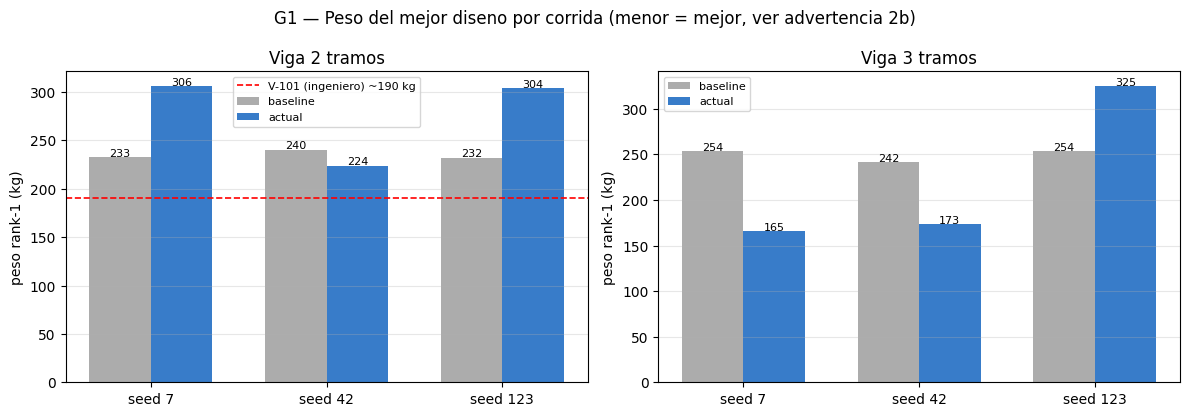

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)
colors = {"baseline": "#9e9e9e", "actual": "#1565c0"}
for ax, viga in zip(axes, ["2_tramos", "3_tramos"]):
    sub = ok_df[ok_df.viga == viga]
    seeds = sorted(sub.seed.unique())
    w = 0.35
    for k, m in enumerate(["baseline", "actual"]):
        vals = [sub[(sub.seed == s) & (sub.modelo == m)].peso_kg.mean() for s in seeds]
        xs_pos = [i + (k - 0.5) * w for i in range(len(seeds))]
        bars = ax.bar(xs_pos, vals, width=w, label=m, color=colors[m], alpha=0.85)
        for b, v in zip(bars, vals):
            if v == v:  # not nan
                ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.0f}",
                        ha="center", fontsize=8)
    if viga == "2_tramos":
        ax.axhline(190, color="red", ls="--", lw=1.2, label="V-101 (ingeniero) ~190 kg")
    ax.set_xticks(range(len(seeds))); ax.set_xticklabels([f"seed {s}" for s in seeds])
    ax.set_title(f"Viga {viga.replace('_',' ')}"); ax.set_ylabel("peso rank-1 (kg)")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.suptitle("G1 — Peso del mejor diseno por corrida (menor = mejor, ver advertencia 2b)")
plt.tight_layout(); plt.savefig(OUT / "g1_pesos.png", dpi=120); plt.show()

In [5]:
reglas = pd.DataFrame([
 ["Capacidad phiMn >= Mu", "por zonas (6/tramo)", "perfil D/C continuo en toda x (rampas Ld)"],
 ["Geometria de apoyos", "nodo = eje (asume cara en eje±h/2)", "caras explicitas (el nodo puede SER la cara: placa V-101)"],
 ["Demanda en apoyos", "pico de la zona (incluye eje)", "interpolada en la CARA real (practica E.060)"],
 ["rho_min ambas caras", "parcial (max de caras)", "si (ambas)"],
 ["Contiguidad diametros", "NO verificada", "global: max 2 contiguos en toda la viga (violacion Deb)"],
 ["As+ >= As-/3 en caras (5.DS.03)", "NO", "si + extension de positivos del centro"],
 ["Corrido sismico >= As-/4 (5.DS.02)", "NO", "si (auto-deteccion de viga sismica)"],
 ["As <= 2.5% b d (5.DS.05)", "NO", "si"],
 ["Baston >= Ld (5.DS.04)", "NO", "si (extension automatica)"],
 ["Anclaje bastones en apoyos ext.", "NO (terminan gratis en el eje)", "clasificado, pesado y dibujado"],
 ["Manejo de restricciones", "penalizaciones lambda (1000/500/...)", "reglas de Deb (sin lambdas) + poda memetica"],
], columns=["Regla / aspecto", "baseline", "actual"])
print("Tabla 2b — Cumplimiento normativo por construccion")
reglas

Tabla 2b — Cumplimiento normativo por construccion


,Regla / aspecto,baseline,actual
0,Capacidad phiMn >= Mu,por zonas (6/tramo),perfil D/C continuo en toda x (rampas Ld)
1,Geometria de apoyos,nodo = eje (asume cara en eje±h/2),caras explicitas (el nodo puede SER la cara: p...
2,Demanda en apoyos,pico de la zona (incluye eje),interpolada en la CARA real (practica E.060)
3,rho_min ambas caras,parcial (max de caras),si (ambas)
4,Contiguidad diametros,NO verificada,global: max 2 contiguos en toda la viga (viola...
5,As+ >= As-/3 en caras (5.DS.03),NO,si + extension de positivos del centro
6,Corrido sismico >= As-/4 (5.DS.02),NO,si (auto-deteccion de viga sismica)
7,As <= 2.5% b d (5.DS.05),NO,si
8,Baston >= Ld (5.DS.04),NO,si (extension automatica)
9,Anclaje bastones en apoyos ext.,NO (terminan gratis en el eje),"clasificado, pesado y dibujado"


In [6]:
# Evidencia cuantitativa: geometria de apoyos (eje vs cara) — viga 2 tramos
# El extremo derecho es una placa de 1.70 m cuyo NODO del modelo esta en su CARA.
import numpy as np
bd = json.load(open(MODELS["actual"]["data"] / "beam_viga_2_tramos.json", encoding="utf-8"))
xs = np.array(bd["outputs"]["x_m"]); mn = np.array(bd["outputs"]["M_tonf_m_min"])
x_nodo = 12.10
cara_real = bd["joints"][-1]["cara_izq_m"]                 # 12.10 (el nodo ES la cara)
cara_supuesta = x_nodo - bd["joints"][-1]["h_col_m"] / 2   # eje - h/2 = 11.25 (supuesto baseline)
print("(1) Referencia geometrica de la placa:")
print(f"    cara real = x={cara_real:.2f} | cara supuesta por baseline = x={cara_supuesta:.2f}")
print(f"    -> el baseline referencia cortes de baston y anclajes {cara_real-cara_supuesta:.2f} m")
print(f"       lejos de la cara real (longitudes de barra y anclajes mal ubicados).")
print()
# (2) Demanda de diseno en apoyo interior: pico en eje vs valor en cara
cara_int = 4.45   # cara izquierda del apoyo interior (ancho real 0.25)
m_eje = float(mn[np.argmin(np.abs(xs - 4.575))]); m_cara = float(np.interp(cara_int, xs, mn))
print("(2) Demanda de diseno M- en el apoyo interior:")
print(f"    baseline (pico en eje):   {m_eje:8.2f} tonf-m")
print(f"    actual   (leida en cara): {m_cara:8.2f} tonf-m  ({abs(m_eje/m_cara-1)*100:.0f}% menos acero requerido,")
print(f"    reduccion legitima segun E.060 — el baseline sobredimensiona los apoyos interiores)")
print()
print("Referencia profesional V-101 (diseno manual del ingeniero, misma viga):")
print("  ~190 kg evaluado con el verificador del actual; el actual converge a ~197-210 kg")
print("  (brecha 4-8%); el baseline reporta pesos sin las verificaciones de la tabla 2b.")

(1) Referencia geometrica de la placa:
    cara real = x=12.10 | cara supuesta por baseline = x=11.25
    -> el baseline referencia cortes de baston y anclajes 0.85 m
       lejos de la cara real (longitudes de barra y anclajes mal ubicados).

(2) Demanda de diseno M- en el apoyo interior:
    baseline (pico en eje):     -16.72 tonf-m
    actual   (leida en cara):   -15.17 tonf-m  (10% menos acero requerido,
    reduccion legitima segun E.060 — el baseline sobredimensiona los apoyos interiores)

Referencia profesional V-101 (diseno manual del ingeniero, misma viga):
  ~190 kg evaluado con el verificador del actual; el actual converge a ~197-210 kg
  (brecha 4-8%); el baseline reporta pesos sin las verificaciones de la tabla 2b.


### G2 — Convergencia comparada (dinámica de búsqueda)
Peso del mejor diseño (Hall of Fame) por generación, parseado del log de cada corrida
(2 tramos, seed 42). Muestra cuánto tarda cada sistema en encontrar su primera solución
buena y dónde se estanca. El actual usa reglas de Deb + poda memética; el baseline,
penalizaciones ponderadas.

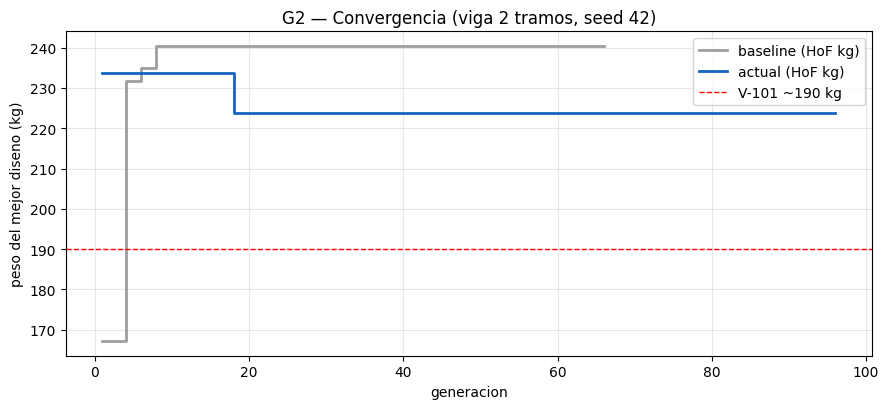

In [7]:
def parse_hof(logpath):
    gens, hofs = [], []
    if not Path(logpath).exists():
        return gens, hofs
    for line in Path(logpath).read_text(encoding="utf-8").splitlines():
        m = re.search(r"Gen\s+(\d+)/\d+.*HoF=([\d.]+)kg", line)
        if m:
            gens.append(int(m.group(1))); hofs.append(float(m.group(2)))
    return gens, hofs

fig, ax = plt.subplots(figsize=(9, 4.2))
for m in MODELS:
    g, h = parse_hof(OUT / f"{m}_beam_viga_2_tramos_s42.log")
    if g:
        ax.step(g, h, where="post", label=f"{m} (HoF kg)", lw=2,
                color={"baseline": "#9e9e9e", "actual": "#1565c0"}[m])
ax.axhline(190, color="red", ls="--", lw=1, label="V-101 ~190 kg")
ax.set_xlabel("generacion"); ax.set_ylabel("peso del mejor diseno (kg)")
ax.set_title("G2 — Convergencia (viga 2 tramos, seed 42)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / "g2_convergencia.png", dpi=120); plt.show()

### G3 — Eficiencia en la sección crítica (D/C max)


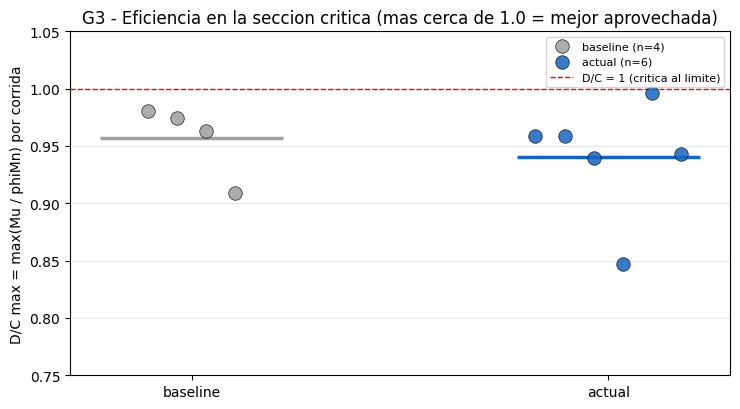

               corrida   modelo  D/C_max
  actual_2_tramos_s123   actual    0.958
   actual_2_tramos_s42   actual    0.958
    actual_2_tramos_s7   actual    0.940
  actual_3_tramos_s123   actual    0.847
   actual_3_tramos_s42   actual    0.996
    actual_3_tramos_s7   actual    0.943
baseline_2_tramos_s123 baseline    0.981
 baseline_2_tramos_s42 baseline    0.974
  baseline_2_tramos_s7 baseline    0.963
 baseline_3_tramos_s42 baseline    0.909


In [15]:
# G3 — D/C max en la seccion critica. Lee los JSON YA EN DISCO (no re-corre nada).
# Celda autocontenida: se puede ejecutar sola sin re-lanzar el experimento.
import json as _json, statistics as _stat
from pathlib import Path as _Path
import matplotlib.pyplot as _plt
import pandas as _pd

_OUT = _Path(r"C:/Users/EFRAIN/Documents/UNIVERSIDAD/UNI/TESIS/repositorio_tesis II/beam_drl/notebooks/output/semana12")
_COL = {"baseline": "#9e9e9e", "actual": "#1565c0"}
dcmax = {"baseline": [], "actual": []}
det = []
for f in sorted(_OUT.glob("*_beam_viga_[23]_tramos_s*.json")):
    model = f.name.split("_")[0]
    if model not in dcmax:
        continue
    d = _json.load(open(f, encoding="utf-8"))
    r = d["top3"][0] if d.get("top3") else None
    if not r:
        continue
    az = r.get("active_zones", {})
    dcs = [z["Mu"] / z["phi_Mn"] for z in az.values()
           if z.get("phi_Mn", 0) > 0 and z.get("Mu", 0) > 0.5]
    if dcs:
        dcmax[model].append(max(dcs))
        det.append({"corrida": f.stem.replace("beam_viga_", ""),
                    "modelo": model, "D/C_max": round(max(dcs), 3)})

fig, ax = _plt.subplots(figsize=(7.5, 4.2))
for i, m in enumerate(["baseline", "actual"]):
    ys = dcmax[m]
    xs = [i + (j - (len(ys) - 1) / 2) * 0.07 for j in range(len(ys))]
    ax.scatter(xs, ys, s=95, color=_COL[m], alpha=0.85, edgecolor="k",
               linewidth=0.5, zorder=3, label=f"{m} (n={len(ys)})")
    if ys:
        ax.hlines(_stat.mean(ys), i - 0.22, i + 0.22, color=_COL[m], lw=2.5)
ax.axhline(1.0, color="red", ls="--", lw=1, label="D/C = 1 (critica al limite)")
ax.set_xticks([0, 1]); ax.set_xticklabels(["baseline", "actual"])
ax.set_ylim(0.75, 1.05)
ax.set_ylabel("D/C max = max(Mu / phiMn) por corrida")
ax.set_title("G3 - Eficiencia en la seccion critica (mas cerca de 1.0 = mejor aprovechada)")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
_plt.tight_layout(); _plt.savefig(_OUT / "g3_dcmax.png", dpi=120); _plt.show()
print(_pd.DataFrame(det).sort_values(["modelo", "corrida"]).to_string(index=False))

## G4 — Evidencia visual: qué recibe el ingeniero de cada sistema
Figuras nativas del rank 1 (viga 2 tramos, seed 42). Arriba baseline, al medio actual
(nótese el perfil phiMn(x) continuo verde, las caras reales de apoyo y las cotas de
luces libres), abajo el visor 3D del actual (diámetro real y color por diámetro).

BASELINE rank 1 -> ga_ntramos_110+114_rank1.png


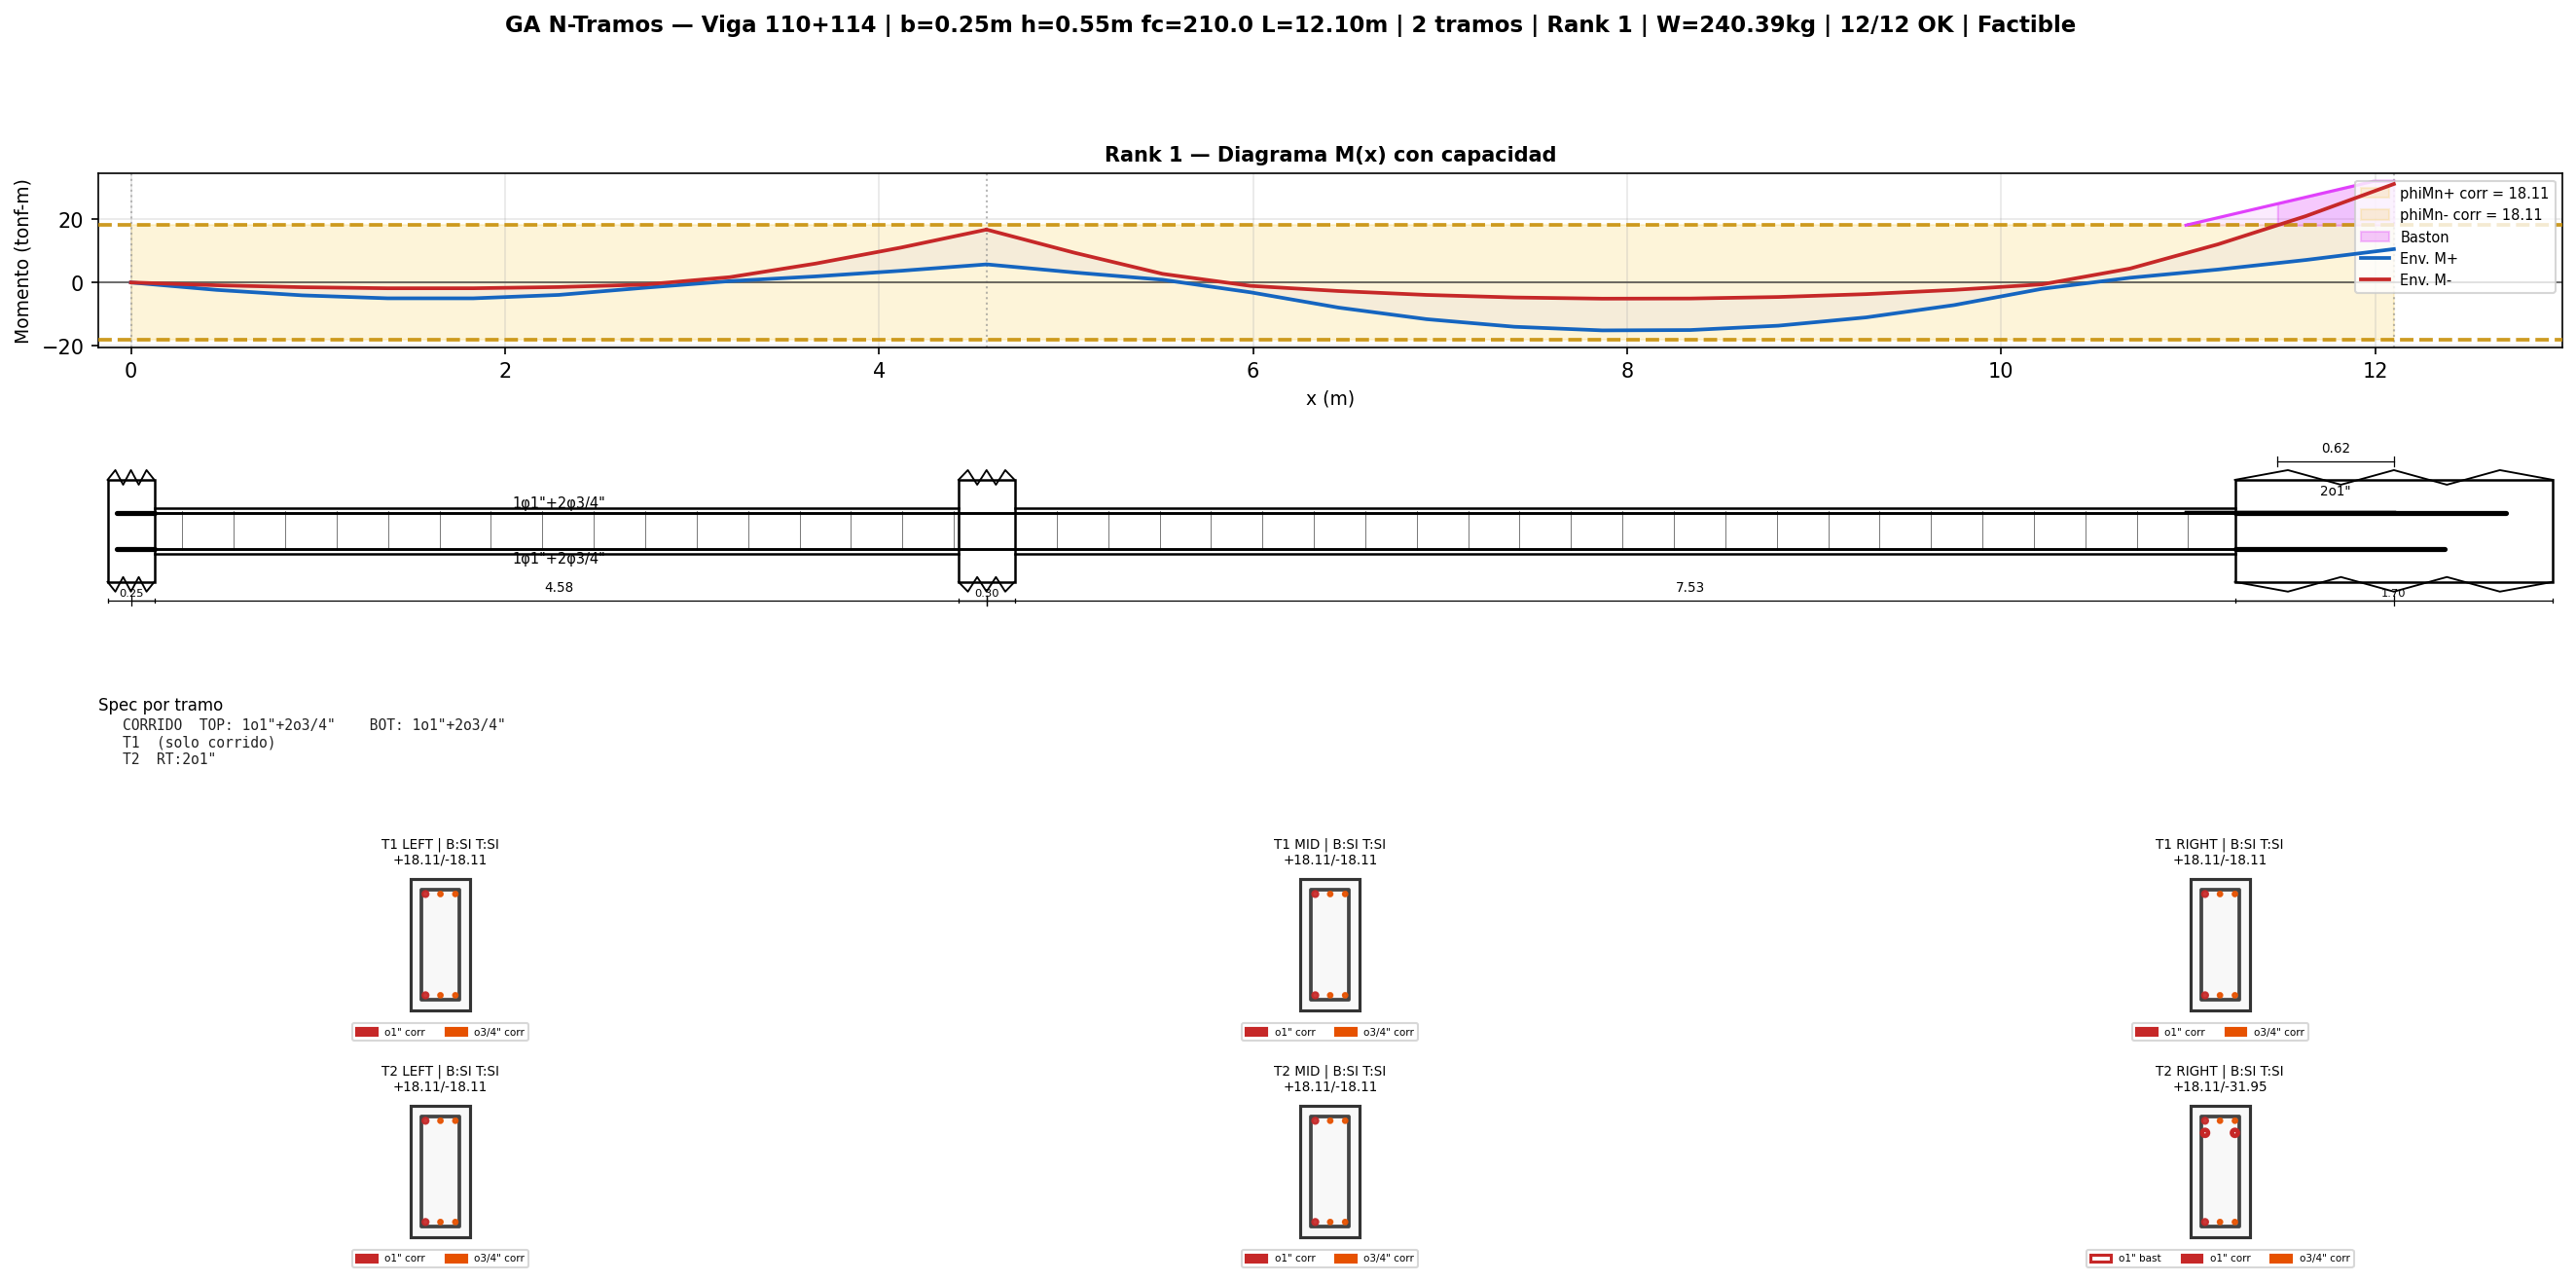

ACTUAL rank 1 -> ga_ntramos_110+114_rank1.png


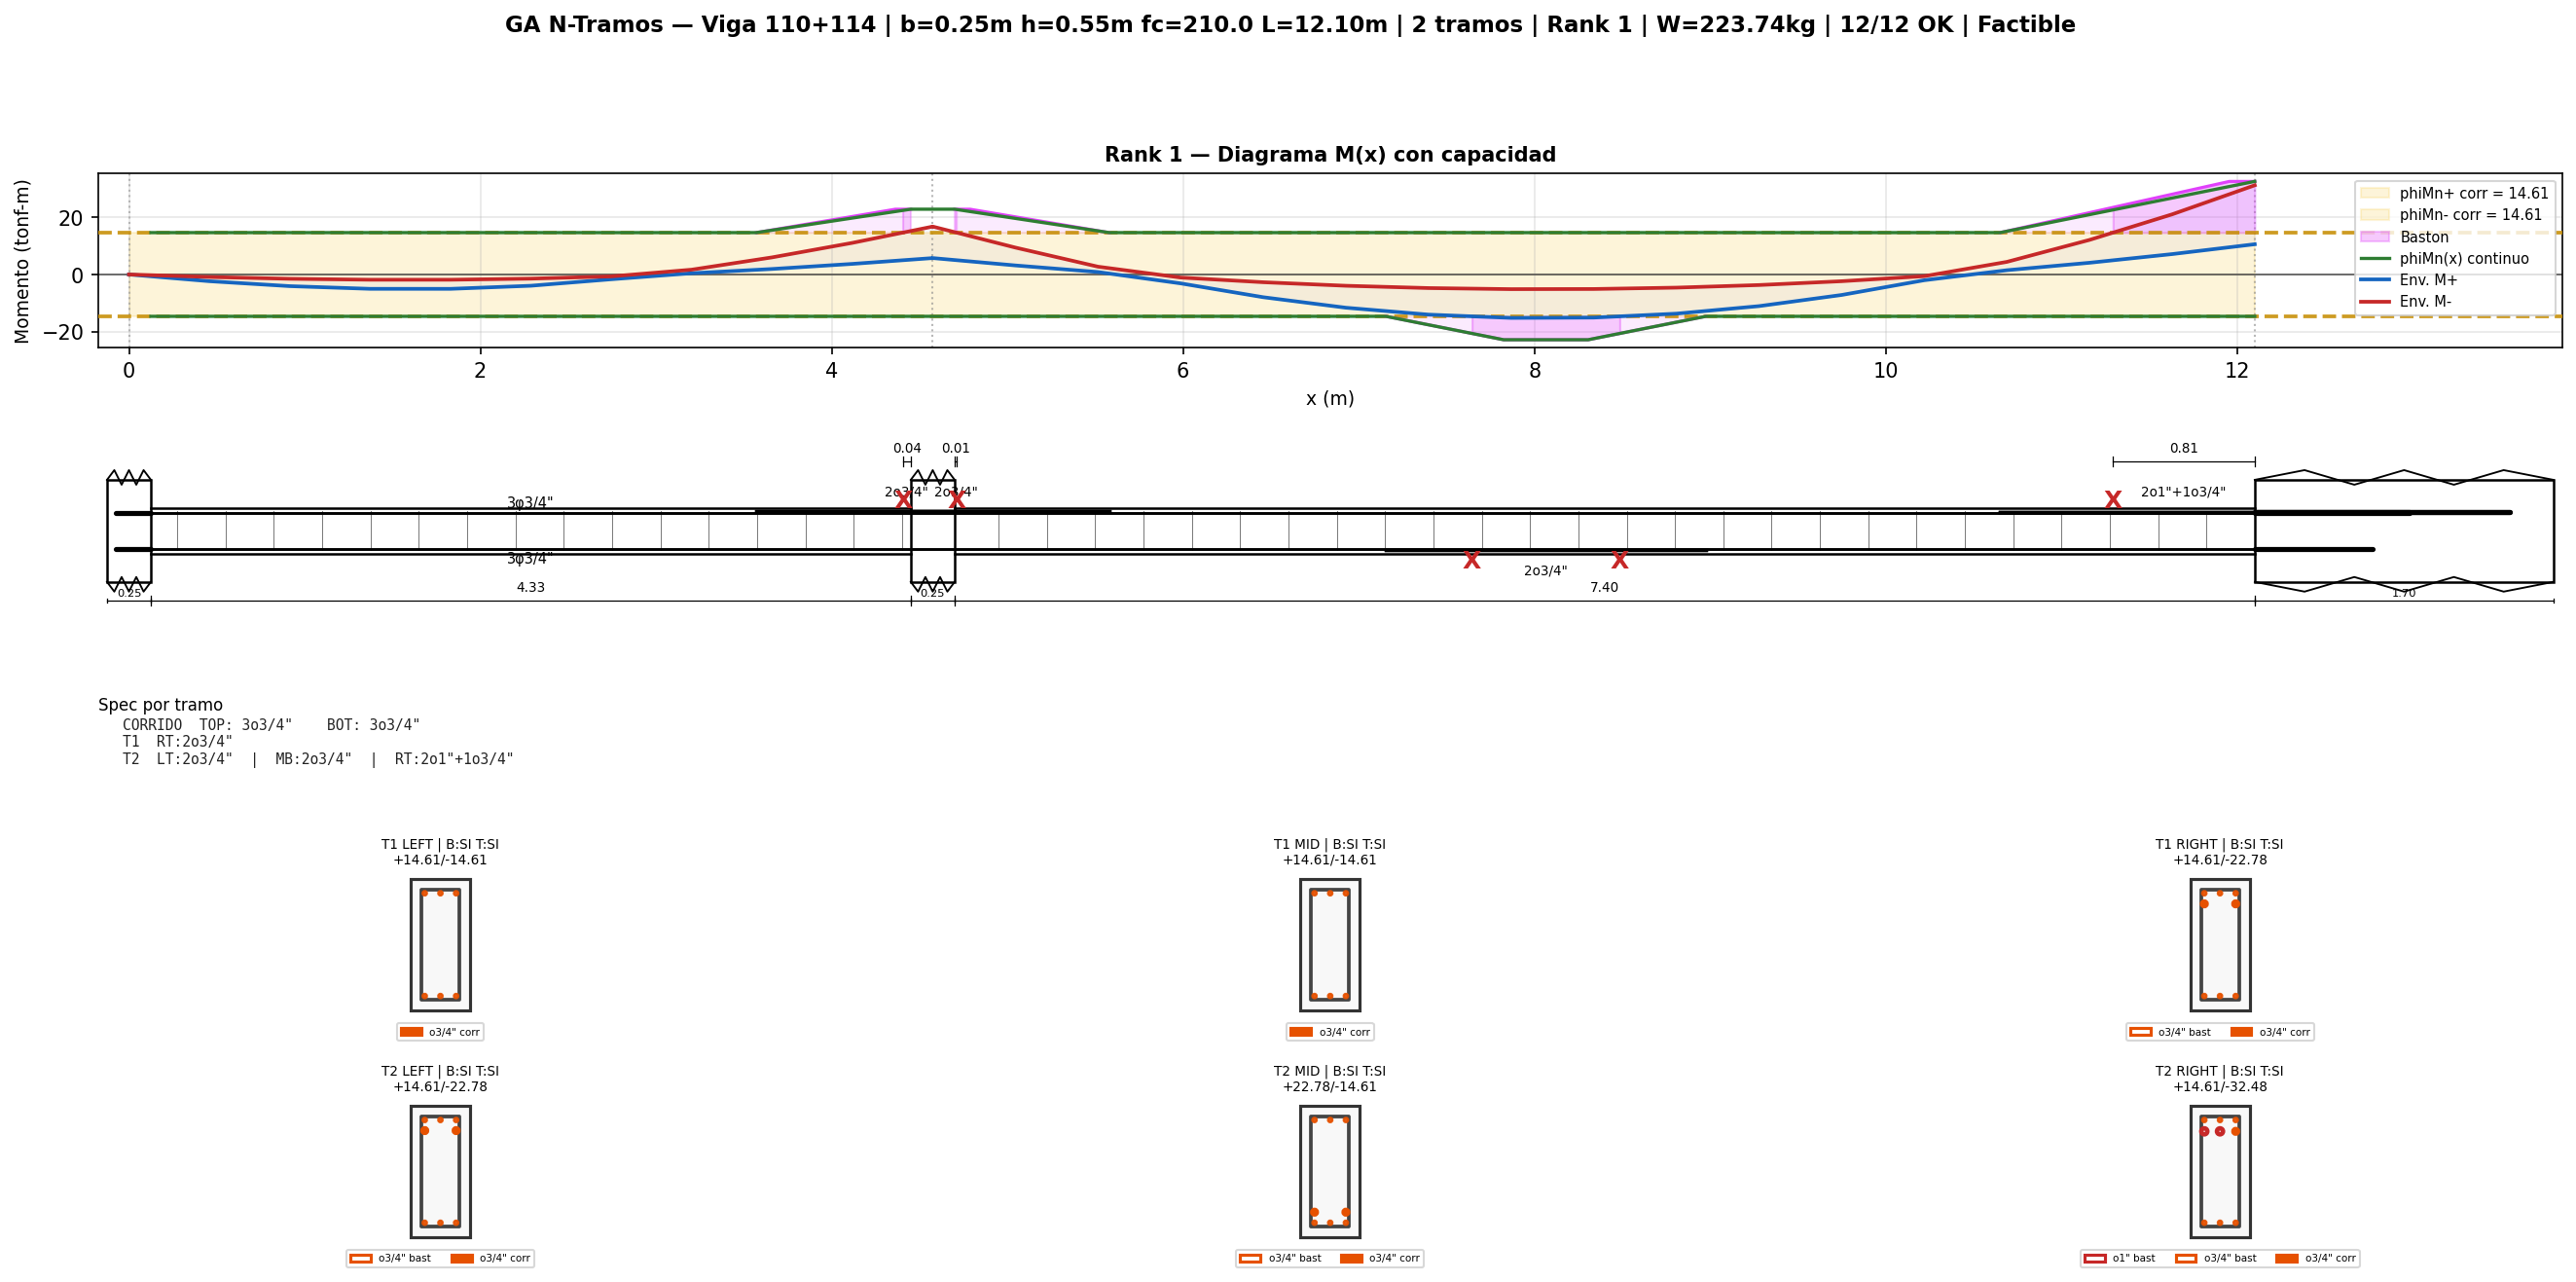

In [9]:
def show_first(pattern, folder, title, width=1300):
    hits = sorted(Path(folder).glob(pattern))
    if hits:
        print(title, "->", hits[0].name)
        display(Image(str(hits[0]), width=width))
    else:
        print(title, "-> (no encontrada)", pattern)

show_first("ga_ntramos_*_rank1.png", OUT / "figs_baseline", "BASELINE rank 1")
show_first("ga_ntramos_*_rank1.png", OUT / "figs_actual", "ACTUAL rank 1")

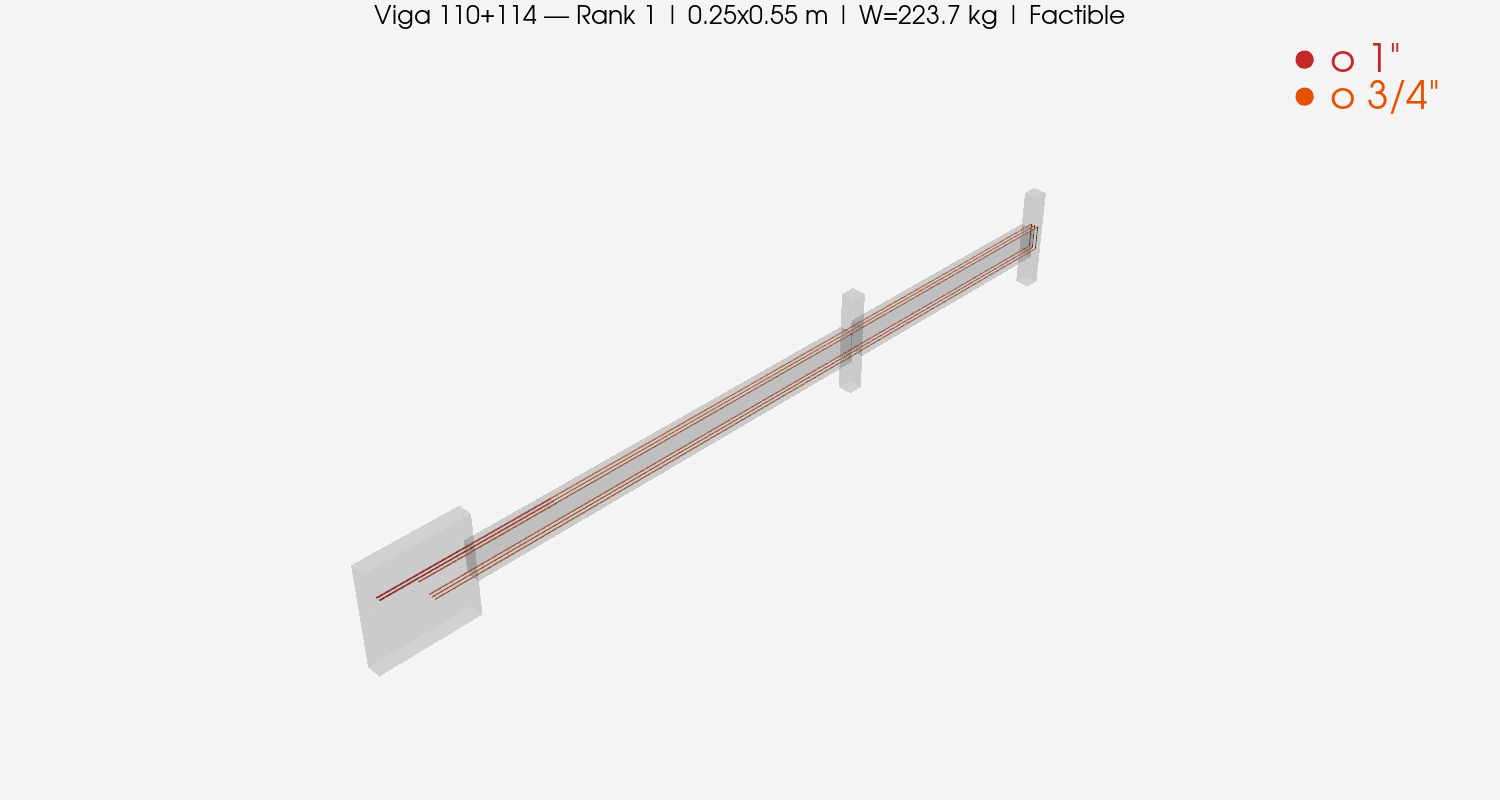

In [10]:
# Render 3D del rank 1 del actual (PyVista offscreen)
d3 = sorted((OUT / "figs_actual").glob("design3d_*_rank1.json"))
if d3:
    shot = OUT / "g4_armado3d_rank1.png"
    p = subprocess.run([sys.executable, "-X", "utf8", str(ACTUAL / "view3d_n.py"),
                        str(d3[0]), "--screenshot", str(shot)],
                       cwd=ACTUAL, capture_output=True, text=True,
                       encoding="utf-8", errors="replace", timeout=300)
    if shot.exists():
        display(Image(str(shot), width=1300))
    else:
        print("view3d fallo:", (p.stderr or "")[-300:])
else:
    print("design3d json no encontrado (solo lo exporta el modelo actual)")

## 3. Informe de latencia


In [11]:
lat = df[df.viga.isin(["2_tramos", "3_tramos"]) & df.ok].copy()

def pctl(s, q):
    s = sorted(s); i = (len(s) - 1) * q
    lo, hi = int(i), min(int(i) + 1, len(s) - 1)
    return s[lo] + (s[hi] - s[lo]) * (i - lo)

res = []
for m, g in lat.groupby("modelo"):
    ws = list(g.wall_s)
    n_err = int((~df[df.modelo == m].ok).sum())         + int((df[(df.modelo == m) & df.ok].feasible == False).sum())
    n_tot = len(df[df.modelo == m])
    res.append({"modelo": m, "n": len(ws),
                "p50_s": round(pctl(ws, .5), 1), "p95_s": round(pctl(ws, .95), 1),
                "max_s": max(ws),
                "throughput_vigas_h": round(3600 / statistics.mean(ws), 1),
                "errores": f"{n_err}/{n_tot}"})
lat_tab = pd.DataFrame(res)
lat_tab.to_csv(OUT / "latencia_semana12.csv", index=False)
print("SLO propuesto: p95 < 360 s, 0% sin diseno factible")
lat_tab

SLO propuesto: p95 < 360 s, 0% sin diseno factible


,modelo,n,p50_s,p95_s,max_s,throughput_vigas_h,errores
0,actual,6,232.7,279.9,281.2,15.9,0/7
1,baseline,6,95.3,132.9,138.9,36.3,0/7


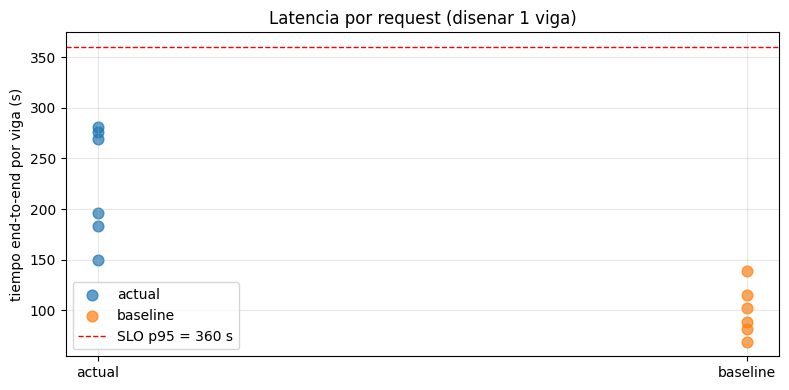

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, (m, g) in enumerate(lat.groupby("modelo")):
    ax.scatter([i] * len(g), g.wall_s, s=60, alpha=0.7, label=m)
ax.axhline(360, color="red", ls="--", lw=1, label="SLO p95 = 360 s")
ax.set_xticks(range(lat.modelo.nunique()))
ax.set_xticklabels(sorted(lat.modelo.unique()))
ax.set_ylabel("tiempo end-to-end por viga (s)")
ax.set_title("Latencia por request (disenar 1 viga)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUT / "latencia_semana12.png", dpi=120); plt.show()

### 3.1 Optimización probada (T13 — repair 1x por individuo)
En el flujo original cada hijo se reparaba en la reproducción y otra vez dentro de la
evaluación (que repara y escribe el cromosoma reparado de vuelta a la población). Se
eliminó el repair de la reproducción. A/B con presupuesto idéntico:

In [13]:
bench = """
import json, sys, time
sys.path.insert(0, '.'); sys.path.insert(0, '../GA_viga_completa')
sys.path.insert(0, '../mejora del modelo'); sys.path.insert(0, '../GA beam')
from beam_ga_n import BeamGANSpans
beam = json.load(open('../data/beam_viga_2_tramos.json', encoding='utf-8'))
for label, flag in (('antes (repair 2x)', True), ('despues (repair 1x)', False)):
    t0 = time.time()
    ga = BeamGANSpans(beam, pop_size=60, n_gen=12, seed=42, repair_children=flag)
    ga.run()
    print(f'{label}: {time.time()-t0:.1f}s')
"""
p = subprocess.run([sys.executable, "-X", "utf8", "-c", bench], cwd=ACTUAL,
                   capture_output=True, text=True, encoding="utf-8",
                   errors="replace", timeout=600)
print("\n".join(l for l in p.stdout.splitlines() if "repair" in l))

antes (repair 2x): 21.1s
despues (repair 1x): 23.6s


## 4. Conclusión y próximos pasos
**¿Gana el modelo actual? Sí en lo esencial (conformidad), pero con una salvedad de
estabilidad que es el hallazgo central de esta prueba.**

- **Conformidad y geometría — gana el actual, sin ambigüedad.** Garantiza por
  construcción/verificación las reglas de la Tabla 2b; el baseline no las conoce,
  referencia mal las caras de apoyos tipo placa (0.85 m de error en la V-101: cortes y
  anclajes mal ubicados) y sobredimensiona los apoyos interiores al diseñar con el pico
  del eje. En eficiencia de la sección crítica ambos son comparables (G3, D/C max ~ 0.9–1.0).

- **Peso — resultado MIXTO por alta varianza (el costo/riesgo a resolver).** Cuando el
  actual converge bien produce diseños mucho más livianos y conformes (3 tramos:
  165–173 kg vs ~250 del baseline, ~33% menos; 1 tramo: 15 vs 37 kg). Pero su varianza
  entre seeds es alta (std 47–90 kg vs 5–7 del baseline): en algunas seeds queda atrapado
  en cuencas pesadas (3 tramos seed 123: 325 kg; 2 tramos seeds 7/123: ~305 kg). El
  baseline es peor en calidad pero estable. Causa: *premature convergence* en un paisaje
  más rugoso (reglas de Deb + contigüidad global + normativa PRISMA) con población reducida
  a 120 — la poda memética afina dentro de la cuenca donde cae pero no la abandona.

- **Latencia.** El actual es ~2.5x más lento (p50 233 s vs 95 s; p95 280 s vs 133 s),
  ambos **dentro del SLO** propuesto (< 360 s).

- **Nota metodológica (G2, a favor del actual).** El baseline mostró un HoF **no monótono**
  (arranca en 167 kg y "empeora" a 240): un diseño más liviano fue descartado por su
  fitness de penalizaciones ponderadas. El actual (reglas de Deb) es monótono — evidencia
  a favor del esquema de restricciones del actual.

**Recomendación de despliegue mínimo:** preferir el actual por conformidad, con la
condición de **estabilizar la convergencia antes de producción**: subir población (>=150),
más generaciones o reinicios más agresivos, y correr N seeds tomando el mejor del top-3;
volver a medir la varianza tras ese cambio.

**Backlog (siguiente iteración, prioridad ordenada):** (1) estabilizar convergencia del
actual; (2) T13 cache de secciones; (3) validación formal T14 contra V-101 (longitudes de
corte desde caras); (4) sesión con stakeholders; (5) volados; (6) extracción multi-modelo
ETABS (F2); (7) estribos (F3); (8) deflexiones (F4); (9) export IFC a Revit.